In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../tissue_dataset.csv")
X = df.drop(columns = ["target", "target_actual"])
y = df["target"]
lasso_features = pd.read_csv("../results/lasso_feature_ranking.csv")
rf_importances = pd.read_csv("../results/rf_importances_ranking.csv")

In [3]:
#MI scoring
mi_scores = mutual_info_classif(
    X,
    y,
    random_state = 42
)
mi_importances = pd.DataFrame({
    "miRNA": X.columns,
    "MI_Score": mi_scores
})
mi_importances = mi_importances.sort_values(
    by =  "MI_Score",
    ascending = False
)

mi_importances.reset_index(
    drop=True,
    inplace = True
)
mi_importances.insert(
    0,
    "Rank",
    range(1, len(mi_importances) + 1)
)
mi_importances.head(20)

,Rank,miRNA,MI_Score
0,1,11102 : hsa-miR-410,0.182592
1,2,147709 : hsa-miR-3185,0.178272
2,3,168791 : hsa-miR-4785,0.177510
3,4,42734 : hsa-miR-2110,0.176669
4,5,168883 : hsa-miR-3689d,0.176637
5,6,42970 : hsa-miR-744-3p,0.174996
6,7,46361 : hsa-miR-1278,0.154438
7,8,169159 : hsa-miR-4521,0.153542
8,9,147897 : hsa-miR-3136-5p,0.152946
9,10,169391 : hsa-miR-513a-3p,0.152928


In [4]:
#Save Ranking list
mi_importances.to_csv(
    "../results/mi_importances_ranking.csv",
    index=False
)

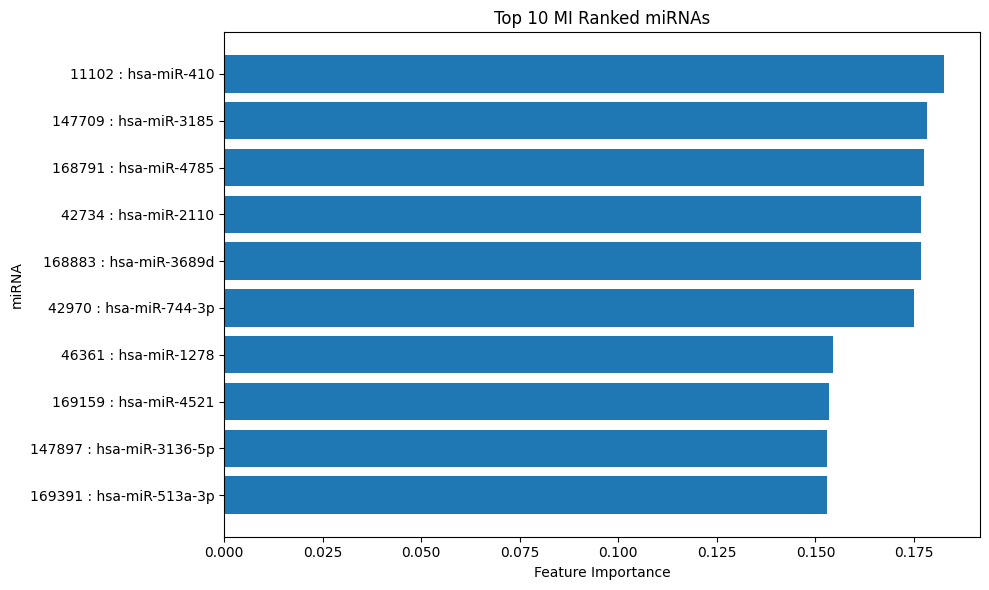

In [5]:
top10 = mi_importances.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["miRNA"],
    top10["MI_Score"]
)

plt.xlabel("Feature Importance")
plt.ylabel("miRNA")
plt.title("Top 10 MI Ranked miRNAs")

plt.gca().invert_yaxis()
plt.savefig(
    "../figures/MI_top10",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

In [6]:
#Consensus Biomarker set 2
mi_top20 = set(
    mi_importances.head(20)["miRNA"]
)

lasso_set = set(
    lasso_features["miRNA"]
)

rf_top20 = set(
    rf_importances.head(20)["miRNA"]
)
lasso_set.intersection(
    rf_top20,
    mi_top20
)

{'147709 : hsa-miR-3185', '168791 : hsa-miR-4785'}

## Mutual Information Feature Ranking Summary

* Data: 133 samples, 1926 miRNAs
* Method: Mutual Information
* Target: Cancer vs Normal
* Feature Ranking Metric: Mutual Information Score

### Key Observation

Mutual Information identified several highly informative miRNAs, including hsa-miR-410, hsa-miR-3185, hsa-miR-4785, and hsa-miR-2110. Comparison with previous ranking methods showed that hsa-miR-3185 and hsa-miR-4785 were consistently selected by LASSO, Random Forest, and Mutual Information.

These miRNAs currently represent the highest-confidence candidate biomarkers identified in the study and will be prioritized for subsequent feature ranking and Incremental Feature Selection (IFS) analyses.
